In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio
from scipy.signal import welch as pwelch


### **RESUMEN**

En esta práctica se realiza una introducción al análisis frecuencial de señales 
discretas y su aplicación en bioseñales, utilizando Python como herramienta 
computacional. Además, se trabaja con señales sintéticas y registros fisiológicos reales 
de ECG y EEG.

Para las señales sintéticas se construyó una señal compuesta por tres componentes 
sinusoidales (40, 80 y 160 Hz), se definió la frecuencia de muestreo adecuada 
según el Teorema de Nyquist-Shannon y se calculó su espectro mediante FFT, 
identificando correctamente cada componente frecuencial. Se verificó la 
reversibilidad del proceso aplicando la IFFT, y se demostró el principio del 
filtrado espectral mediante la anulación selectiva de coeficientes en el dominio 
de la frecuencia, extrayendo cada sinusoide de forma independiente.

Para las bioseñales, se analizó una señal ECG adquirida a 250 Hz mediante el 
periodograma de Welch con ventana Hanning (500 muestras, 50% de solapamiento), 
identificando y eliminando ruido de red eléctrica en 60 Hz mediante filtrado 
espectral. Finalmente, se realizó un análisis comparativo entre señales EEG de 
49 sujetos control y 49 pacientes con Parkinson en los canales C3 y C4. Los 
resultados mostraron un incremento de potencia en la banda delta (~+21% en ambos 
canales) y reducciones en las bandas theta y alpha en los pacientes con Parkinson.

### **INTRODUCCIÓN: nuevas funciones usadas**


La Transformada Discreta de Fourier (DFT) requiere $N^2$ operaciones matemáticas, 
lo que la hace computacionalmente costosa para señales largas. El algoritmo FFT 
(*Fast Fourier Transform*) de Cooley-Tukey calcula exactamente el mismo resultado 
usando solo $N \log_2 N$ operaciones, representando una reducción dramática del 
tiempo de cómputo. Por ejemplo, para $N = 1000$ muestras, la DFT requiere 
1,000,000 operaciones mientras que la FFT solo ~10,000. El resultado matemático 
es idéntico: la FFT es simplemente una implementación eficiente de la DFT, razón 
por la cual es el algoritmo estándar en el análisis espectral de señales.

Por otra parte, la Transformada Inversa de Fourier (IFFT) realiza el proceso inverso a la FFT: 
a partir del espectro frecuencial $X(k)$, reconstruye la señal original en el 
dominio del tiempo $x(n)$ mediante la expresión:

$$x(n) = \frac{1}{N} \sum_{k=0}^{N-1} X(k) \cdot e^{j2\pi kn/N}$$

En Python se implementa con `np.fft.ifft()`, que devuelve un array de números 
complejos. Dado que la señal original es real, se extrae únicamente la parte real 
con `np.real()`, descartando las componentes imaginarias que son errores numéricos 
de punto flotante del orden de $10^{-15}$.

### **RESULTADOS Y DISCUSIÓN**
A continuación se muestra la realización de puntos que ya se consignaban en el taller, para luego resolver los puntos de aplicación con su respectivo análisis.

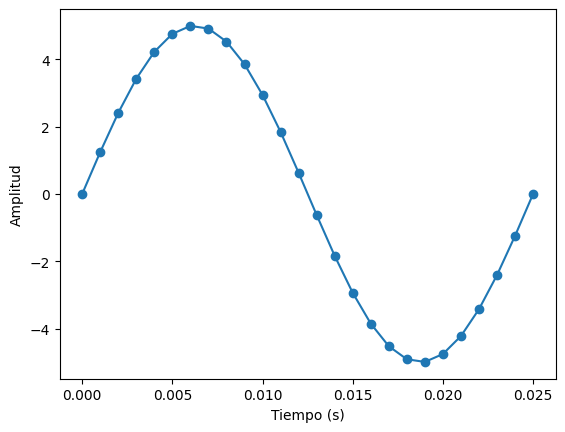

In [3]:
Fo = 40 # Frecuencia fundamental de la señal
Tp = 1/Fo # Periodo de la señal
Fs = 1000 # Frecuencia de muestreo
T = 1/Fs # Periodo de muestreo
t = np.arange(0, Tp+T, T) # Tiempo para un ciclo de la señal con duración de Tp más una muestra T
A = 5
x = A*np.sin(2*np.pi*Fo*t)
plt.plot(t, x, marker='o')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.show()

Se observa claramente que el periodo de la señal analógica o en tiempo continuo es 𝑇𝑝=0,025𝑠.

Una manera alternativa de crear la señal 𝑥(𝑛) sería:

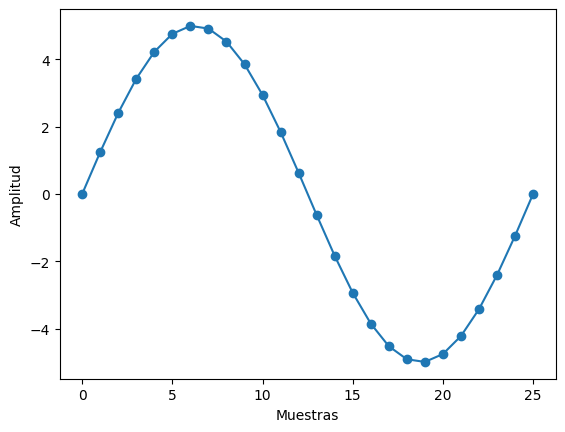

In [4]:
fo = Fo/Fs
n = np.arange(0, len(t))
x1 = A*np.sin(2*np.pi*fo*n)
plt.plot(n, x1, marker='o')
plt.xlabel('Muestras')
plt.ylabel('Amplitud')
plt.show()

En este caso se observa claramente que el periodo de la señal en tiempo discreto es 𝑁=25 muestras. La señal 𝑥1(𝑛) se ha generado mediante la pulsación de oscilación en tiempo discreto 𝑓0=0,04 muestras/s. La única diferencia respecto al anterior es que en este último caso el período
Introducción al análisis frecuencial de señales Bioseñales y sistemas
de muestreo 𝑇 “manipula” la pulsación original 𝐹0 y se considera como eje temporal la sucesión de números enteros correspondiente a los instantes de muestreo.

Otra manera de graficar las señales muestreadas es mediante la función stem:

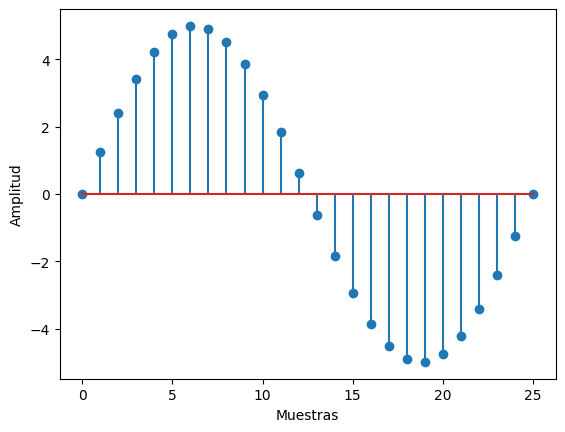

In [5]:
plt.stem(n, x1)
plt.xlabel('Muestras')
plt.ylabel('Amplitud')
plt.show()

In [6]:
# La energía, medida en 𝑉2 ó 𝑊.𝑠 en un ciclo de la señal 𝑥(𝑛) se puede hallar de la siguiente manera:
energia = sum(x**2)
#La potencia media de la señal medida en 𝑊 es:
potencia = energia/(len(t)-1)
#El valor cuadrático medio es la raíz cuadrada de la potencia:
rms = np.sqrt(potencia)

Para hallar la energía, así como la potencia media de la señal considerando 10 ciclos de la sinusoide (250ms):

In [7]:
t10 = np.arange(0,10*Tp+T,T)
x10 = A*np.sin(2*np.pi*Fo*t10)
energia10 = sum(x10**2)
potencia10 = energia10/(len(t10)-1)
rms10 = np.sqrt(potencia10)

La transformada Discreta de Fourier (o de forma abreviada, DFT, por sus siglas en inglés) de una señal 𝑥(𝑛) se calcula en Python mediante el comando np.fft.fft

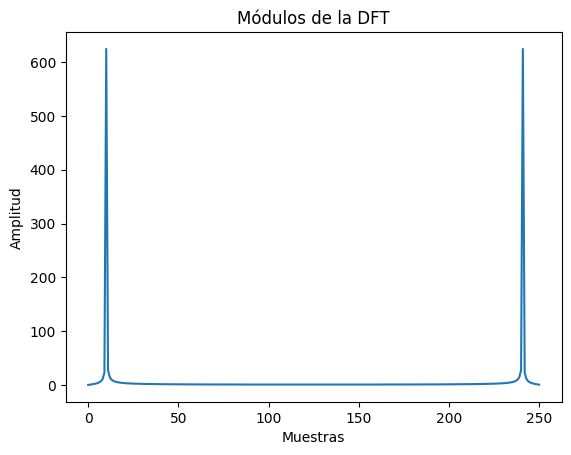

In [8]:
X10 = np.fft.fft(x10)
plt.plot(abs(X10))
plt.title('Módulos de la DFT')
plt.xlabel('Muestras')
plt.ylabel('Amplitud')
plt.show()

Se puede observar que la DFT obtenida tiene el mismo número de puntos como muestras tiene la señal 𝑋10(𝑛), 250 en total.
También vemos que el valor máximo que toman los coeficientes es de 625.

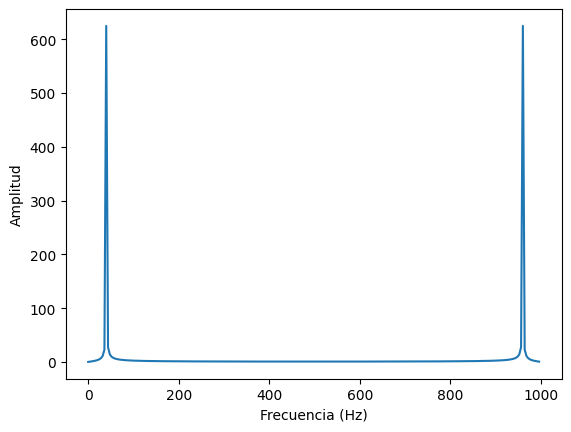

In [9]:
N = len(X10)
F = np.arange(0,N)*Fs/N
plt.plot(F,abs(X10))
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Amplitud')
plt.show()

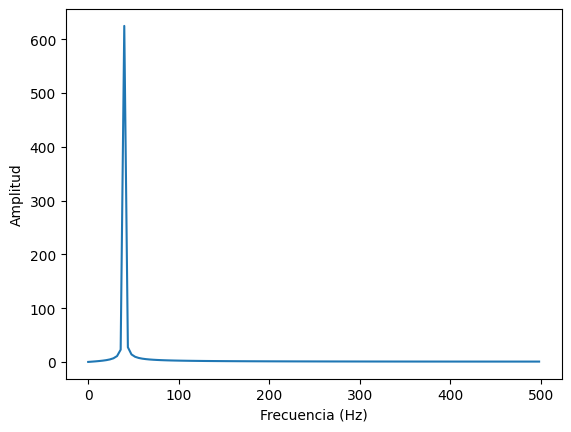

In [10]:
Nmitad = int(np.ceil(N/2))
Fmitad = np.arange(0,Nmitad)*Fs/N
X10mitad = X10[0:Nmitad]
plt.plot(Fmitad,abs(X10mitad))
plt.ylabel('Amplitud')
plt.xlabel('Frecuencia (Hz)')
plt.show()

Realizando un zoom se observa que la componente frecuencial se encuentra ubicada a 40 Hz.

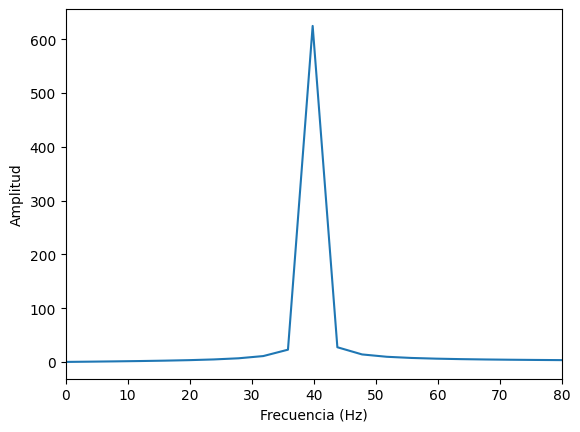

In [11]:
plt.plot(Fmitad,abs(X10mitad))
plt.ylabel('Amplitud')
plt.xlabel('Frecuencia (Hz)')
plt.xlim(0,80)
plt.show()

#### **APLICACION**

**4.1 Cree una señal que sea la suma de tres componentes sinusoidales con frecuencias de 40, 80 y 160 Hz. Defina la frecuencia de muestreo mínima necesaria para representar la señal, y utilice la frecuencia de muestreo necesaria para representarla apropiadamente**

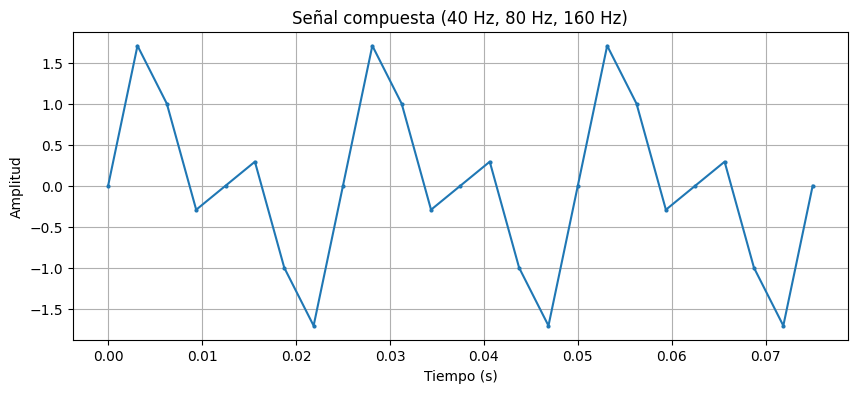

In [12]:
#Frecuencias fundamentales (Hz)
f1 = 40
f2 = 80
f3 = 160

#Calculo de frecuencia de muestreo (Hz)
fs_minima = 320 # Por Teorema de Nyquist (2 * 160 Hz) Se toma 160 debido a que fs >= 2fmax y en este caso fmax =160
fs1 = fs_minima*1 

#Vector de tiempo
# La frecuencia fundamental es 40Hz, su periodo es T = 1/40 = 0.025s.
#Se crea un vector tiempo que tenga la duracion de 3 veces la duracion de la frecuencia fundamental
Tp1 =(1/40)*3 
t1 = np.arange(0, Tp1, 1/fs1)

# Creación de la señal compuesta
sig1 = np.sin(2*np.pi*f1*t1)+np.sin(2*np.pi*f2*t1)+np.sin(2*np.pi*f3*t1)

#Grafica de la señal en el tiempo
plt.figure(figsize=(10, 4))
plt.plot(t1, sig1, marker='.', markersize=4) 
plt.title('Señal compuesta (40 Hz, 80 Hz, 160 Hz)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.grid(True)
plt.show()

Al intentar graficar la señal tomando la frecuencia minima como la frecuencia para la sinosoidal es posible observar que la cantidad de puntos no son suficientes para describir la dinamica de la señal puesto que mas alla de representar una señal seno, esta graficando una señal con puntas marcadas o dentada, lo que quiere decir que la frecuencia de muestreo debe ser mayor para describir de mejor manera la dinamica de la señal

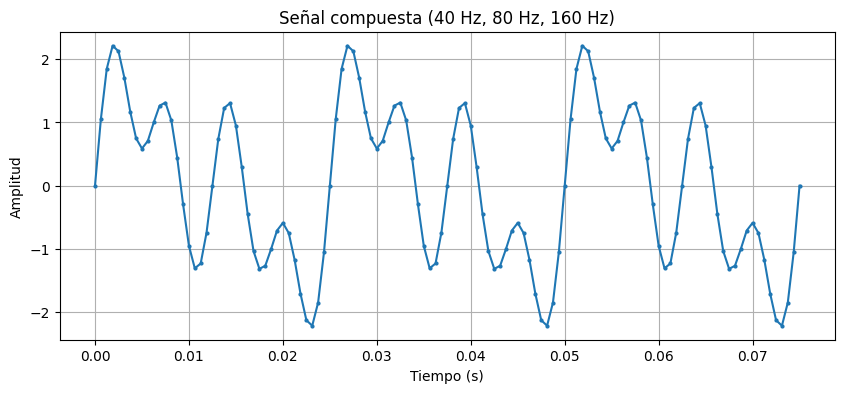

In [13]:
#Calculo de frecuencia de muestreo Frecuencias de muestreo (Hz)
'''Si bien por Teorema de Nyquist la fs debe ser minimo 2fmax, esta señal no permite
describir la dinamica de la señal de manera correcta, por lo que para lograr esto
se opta por tomar una frecuencia de muestreo mayor a 2fmax'''
fs2 = fs_minima*5 


#Vector de tiempo
# La frecuencia fundamental es 40Hz, su periodo es T = 1/40 = 0.025s.
#Se crea un vector tiempo que tenga la duracion de 3 veces la duracion de la frecuencia fundamental, se meustren 3 repeticiones
Tp2 =(1/40)*3 
t2 = np.arange(0, Tp2, 1/fs2)

# Creación de la señal compuesta
sig = np.sin(2*np.pi*f1*t2)+np.sin(2*np.pi*f2*t2)+np.sin(2*np.pi*f3*t2)

#Grafica de la señal en el tiempo
plt.figure(figsize=(10, 4))
plt.plot(t2, sig, marker='.', markersize=4) 
plt.title('Señal compuesta (40 Hz, 80 Hz, 160 Hz)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.grid(True)
plt.show()

Este resultado nos muestra tres ciclos de la señal donde se superponen las tres componentes de 40, 80 y 160 Hz. Tiene variaciones de amplitud entre aprox. -2.3 y +2.3.

La frecuencia de muestreo mínima teórica es 320 Hz, pero se obtenían pocas muestras dejando una distorsión de las ondas. Al usar 1600 Hz, se obtienen suficientes muestras para representar fielmente la dinámica de todas las componentes, especialmente la de 160 Hz.


**4.2 Calcule la transformada de Fourier de la señal y grafique el espectro de frecuencia. Identifique en el espectro las frecuencias que componen la señal (trabaje con 10 periodos de la señal)**

Para este caso, el vector de tiempo debe cambiar porque se trabajara con 10 periodos de la señal:

La frecuencia fundamental es 40Hz, su periodo es T = 1/40 = 0.025s, por lo que 10 periodos equivalen a 0.25 segundos.

Numero total de muestras: 121


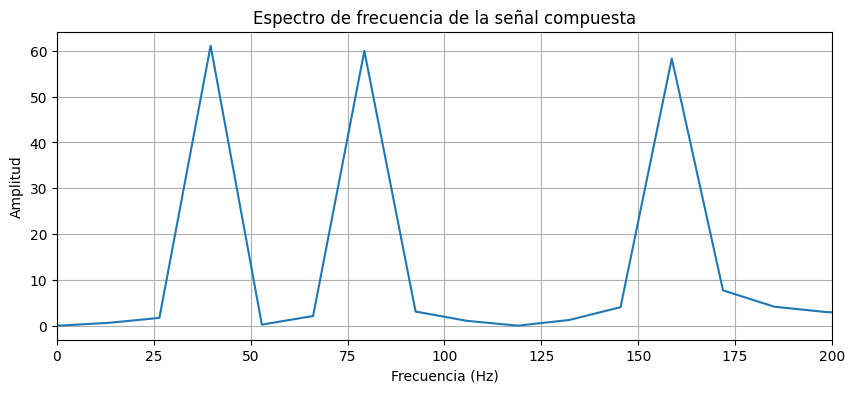

In [14]:
# Cálculo de la Transformada de Fourier
FFT_Sig = np.fft.fft(sig)

#Creación del vector de frecuencias en Hz
N = len(sig) # Número total de muestras
F = np.arange(0, N) * fs2 / N # Escalamiento del eje X a Hz (genera valores de k y los mulltiplica por fs/N)
print(F"Numero total de muestras: {N}")
#Partir el espectro a la mitad (hasta la frecuencia Nyquist)
N_mitad = int(np.ceil(N/2))
F_mitad = F[0:N_mitad]
X_mitad = FFT_Sig[0:N_mitad]

#Graficar el espectro de frecuencia
plt.figure(figsize=(10, 4))
plt.plot(F_mitad, np.abs(X_mitad)) # Usamos abs() para obtener la magnitud o amplitud
plt.title('Espectro de frecuencia de la señal compuesta')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Amplitud')

#Hacemos un zoom en el eje X (hasta 200 Hz) para ver claramente nuestros picos
plt.xlim(0, 200) 
plt.grid(True)
plt.show()

El espectro de frecuencia muestra tres picos de amplitud ubicados en 40, 80 y 160 Hz, correspondiendo exactamente a las tres componentes sinusoidales que conforman la señal. Los tres picos presentan amplitudes similares (~60) lo cual es consistente con que las tres sinusoides fueron definidas con la misma amplitud unitaria.

El espectro se graficó únicamente hasta la frecuencia de Nyquist (800 Hz), pues la segunda mitad del espectro es simpétrica para señales reales. Por otro lado, el ancho notrio de los picos responde a la resolución frecuencial finita ($\Delta f = f_s/N$), la cual mejoraría con un mayor número de muestras. Cabe destacar además que las frecuencias de 80 y 160 Hz corresponden al segundo y cuarto armónico de la frecuencia fundamental de 40 Hz, lo que se refleja en que sus posiciones en el espectro son exactamente el doble y el cuádruple de la frecuencia base.


**4.3 Consulte la función que permite realizar el cálculo de la transformada inversa de Fourier. Aplíquelo a la señal anterior**

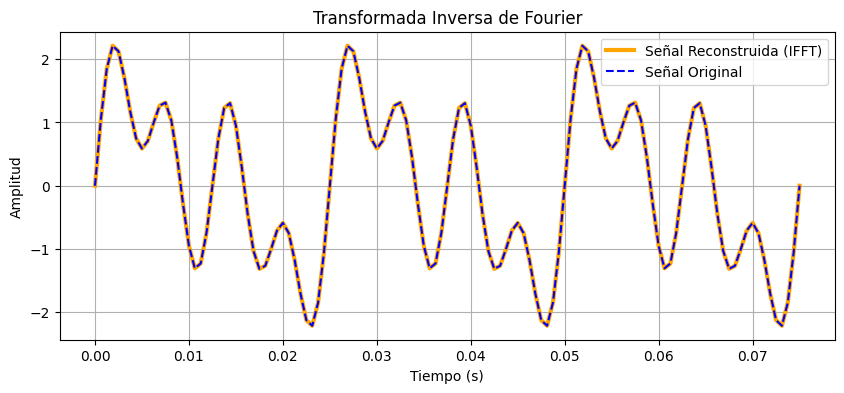

In [15]:
# Aplicar la Transformada Inversa de Fourier
x_reconstruida = np.fft.ifft(FFT_Sig) 

#Graficación de la señal reconstruida 
plt.figure(figsize=(10, 4))

plt.plot(t2, np.real(x_reconstruida), label='Señal Reconstruida (IFFT)', color='orange', linewidth=3)

#Graficación de la señal original vs Reconstruida a modo de comparativa
plt.plot(t2, sig, linestyle='dashed', label='Señal Original', color='blue')

plt.title('Transformada Inversa de Fourier')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.legend()
plt.grid(True)
plt.show()

La figura muestra la superposición de la señal original (azul punteada) y la señal 
reconstruida mediante IFFT (naranja), observándose una coincidencia prácticamente 
perfecta entre ambas en todo el intervalo temporal. Esto verifica empíricamente la 
reversibilidad del par transformado DFT–IDFT: la información contenida en el dominio 
del tiempo se conserva íntegramente al pasar al dominio de la frecuencia y viceversa, 
propiedad garantizada matemáticamente por el Teorema de Parseval (la energía de la señal se conserva entre los dos dominios).

**4.4. ¿Podría decir que las siguientes líneas aplican un filtro? ¿Por qué?**

* **F1 = np.fft.fft(x)**; Esta linea toma la señal original y la transforma al dominio de la frecuencia..

* **F2 = np.zeros((len(F1)))**; Al crear un vector de ceros, se crea un espectro neutro o "en blanco" (lleno de ceros) del mismo tamaño que el original (F1 para este caso). Lo que podria hacerse con la finalidad de reiniciar todas las freciencias o comenzarlas en 0 para su posterior tratamiento

* **F2[9:13] = F1[9:13]**; Esta linea crea un filtro que copia los valores de F1 en un rango determinado (9 al 12) y los asigna a F2 en el mismo rango previamente mencionado. Como F2 era el espectro de ceros, todos los valores continuaran siendo 0 exceptuando los asignados, este comportamiento corresponde a un filtro pasa bandas que permite el paso de esta banda en particular (Frecuencias de la posicion 9 a la 12) y elimina o no tiene en cuenta el resto

* **xr = np.fft.ifft(F2)**; Al aplicar la Transformada Inversa de Fourier sobre el espectro F2, la señal que regresa al tiempo (xr) ya no tendrá todas las frecuencias que podia poseer anteriormente, sino únicamente aquellas que fueron asignadas por medio del corte o la asignacion del filtro pasa-bandas.

En conclusión, **sí**, estas líneas aplican un filtro. Un filtro es cualquier 
operación que modifica selectivamente el contenido frecuencial de una señal, 
conservando algunas frecuencias y eliminando otras. Exactamente eso es lo que 
ocurre aquí: se conservan únicamente las frecuencias de los índices 9 a 12 y se 
anulan todas las demás, lo que corresponde a un **filtro pasa-bandas ideal** 
implementado en el dominio de la frecuencia.

Las siguientes lineas de codigo sirven para visualizar graficamente la señal resultante despues de aplicar el filtro a la señal 



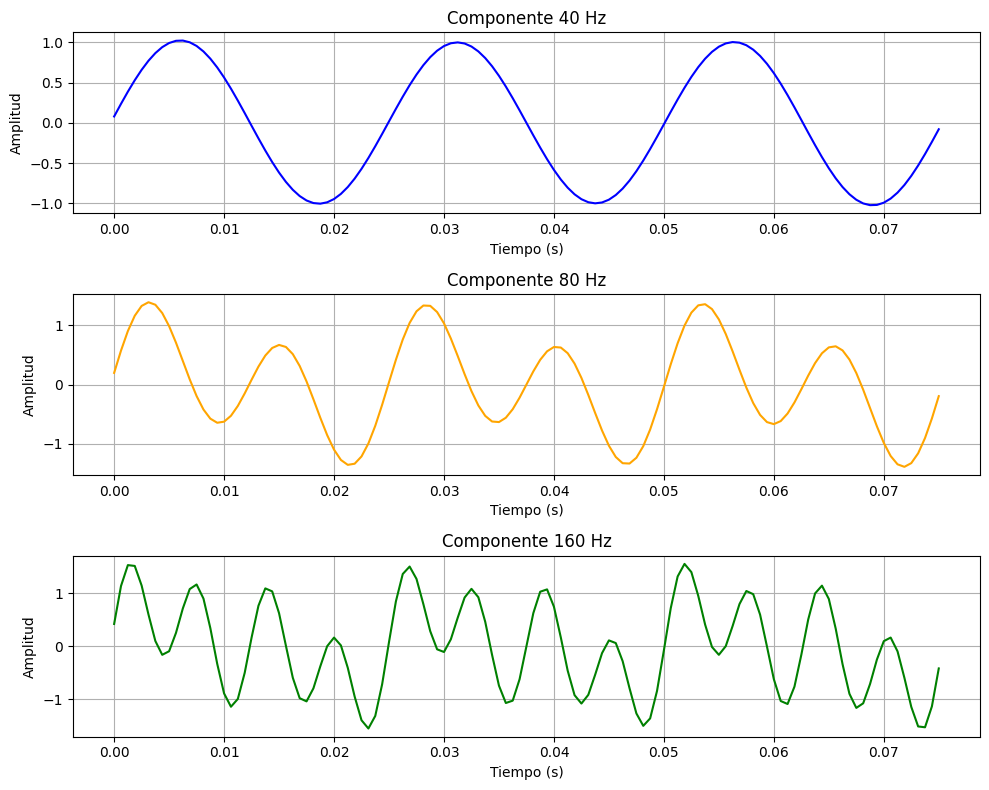

In [21]:
# Extracción de cada componente frecuencial

# Componente de 40 Hz (índices 3 y su espejo N-3)
F2_40 = np.zeros(N, dtype=complex)
F2_40[3:4] = FFT_Sig[3:4]
F2_40[N-3:N] = FFT_Sig[N-3:N]  # parte simétrica
xr_40 = np.fft.ifft(F2_40)

# Componente de 80 Hz (índices 6 y su espejo N-6)
F2_80 = np.zeros(N, dtype=complex)
F2_80[6:7] = FFT_Sig[6:7]
F2_80[N-6:N] = FFT_Sig[N-6:N]
xr_80 = np.fft.ifft(F2_80)

# Componente de 160 Hz (índices 12 y su espejo N-12)
F2_160 = np.zeros(N, dtype=complex)
F2_160[12:13] = FFT_Sig[12:13]
F2_160[N-12:N] = FFT_Sig[N-12:N]
xr_160 = np.fft.ifft(F2_160)

# Graficar las tres componentes
fig, axes = plt.subplots(3, 1, figsize=(10, 8))

axes[0].plot(t2, np.real(xr_40), color='blue')
axes[0].set_title('Componente 40 Hz')
axes[0].set_xlabel('Tiempo (s)')
axes[0].set_ylabel('Amplitud')
axes[0].grid(True)

axes[1].plot(t2, np.real(xr_80), color='orange')
axes[1].set_title('Componente 80 Hz')
axes[1].set_xlabel('Tiempo (s)')
axes[1].set_ylabel('Amplitud')
axes[1].grid(True)

axes[2].plot(t2, np.real(xr_160), color='green')
axes[2].set_title('Componente 160 Hz')
axes[2].set_xlabel('Tiempo (s)')
axes[2].set_ylabel('Amplitud')
axes[2].grid(True)

plt.tight_layout()
plt.show()

Las tres componentes sinusoidales (40, 80 y 160 Hz) fueron extraídas correctamente, 
presentando forma sinusoidal pura y amplitudes unitarias consistentes con la señal 
original. La extracción se realizó conservando únicamente los coeficientes FFT del 
índice k correspondiente a cada frecuencia y su simétrico (N-k), anulando el resto, 
lo que equivale a aplicar un filtro pasa-bandas independiente para cada componente. 
Incluir el índice simétrico es indispensable, ya que una sinusoide real requiere tanto 
su frecuencia positiva como negativa en el espectro para reconstruirse correctamente, 
de lo contrario la IFFT devuelve una señal con amplitud reducida a la mitad. El 
resultado confirma que la señal compuesta es la superposición lineal de las tres 
sinusoides y que el filtrado espectral permite separarlas de forma independiente.

**4.5. El archivo adjunto (senecg.mat) contiene una señal de ECG adquirida a una frecuencia de muestreo de 250 Hz. Realice un análisis en frecuencia de la señal usando periodogramas de Welch y determine si es necesario eliminar ruido, en tal caso, elimínelo de la forma que se mostró antes y compruebe que lo haya realizado, calcule la transformada inversa de Fourier de la señal filtrada y compruebe con el periodograma. (Usar una ventana Hanning, y justificar la elección del solapamiento y el ancho de la ventaja)**

In [16]:
#Carga del archivo .mat
data = sio.loadmat('senecg.mat')
data.items()


dict_items([('__header__', b'MATLAB 5.0 MAT-file, Platform: PCWIN64, Created on: Tue Dec 01 10:48:54 2015'), ('__version__', '1.0'), ('__globals__', []), ('ECG', array([[ 0.16479384],
       [-0.00455636],
       [-0.23589197],
       ...,
       [ 0.00518452],
       [-0.18447972],
       [ 0.015     ]]))])

In [17]:
Long= data['ECG']
num = len(Long)
print(f'La longitud del vector es ECG:',num)


La longitud del vector es ECG: 1250


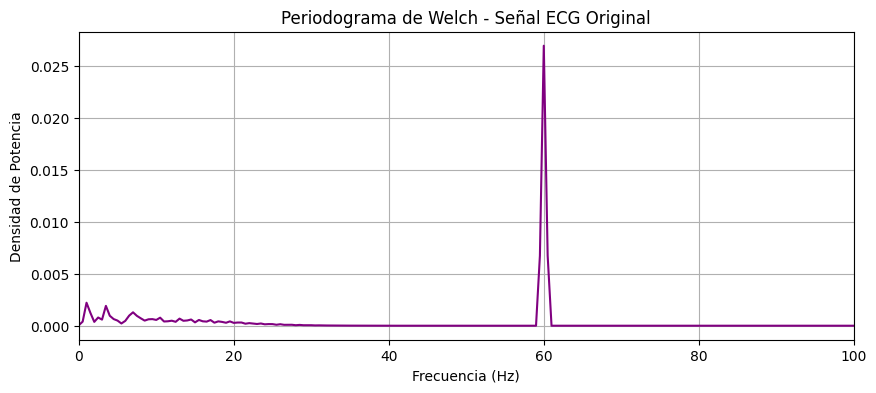

In [18]:
llaves = [k for k in data.keys() if not k.startswith('__')]
# Extraemos la señal y la aplanamos para que quede como un vector simple (1D)
ecg_original = data[llaves[0]].flatten() 

fs_ecg = 250 # Frecuencia de muestreo indicada en la guía

# Configuración del Periodograma de Welch
nperseg = 500  # Ventana de 500 muestras (2 segundos)
noverlap = 250 # Solapamiento del 50%

# Cálculo de Welch
f_w, Pxx_w = pwelch(ecg_original, fs_ecg, window='hann', nperseg=nperseg, noverlap=noverlap)

# 3. Graficar el periodograma para detectar el ruido
plt.figure(figsize=(10, 4))
plt.plot(f_w, Pxx_w, color='purple')
plt.title('Periodograma de Welch - Señal ECG Original')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Densidad de Potencia')
plt.xlim(0, 100) # Miramos solo hasta 100Hz para no saturar la vista
plt.grid(True)
plt.show()

En la figura obtenida se presenta la estimación de la Densidad Espectral de Potencia (PSD) de la señal de electrocardiograma (ECG) original utilizando el método del Periodograma de Welch. Se empleó una ventana de Hanning con un ancho de 500 muestras (equivalente a 2 segundos de señal, dado que la frecuencia de muestreo es de 250 Hz) y un solapamiento del 50% (250 muestras).

El ancho de 500 muestras garantiza una resolución en frecuencia de 0.5 Hz, una precisión óptima para discriminar componentes de ruido. Asimismo, el solapamiento del 50% permite recuperar la información atenuada en los bordes de las ventanas, estabilizando la varianza del espectro resultante.

El corazón humano tiene la mayoría de su energía en frecuencias bajas (0 a 40 Hz aproximadamente), por lo que es normal ver picos pequeños en estos valores, sin embargo, el pico que se presenta en 60 Hz es ruido de red eléctrica Por lo que se elimina de la siguiente forma:

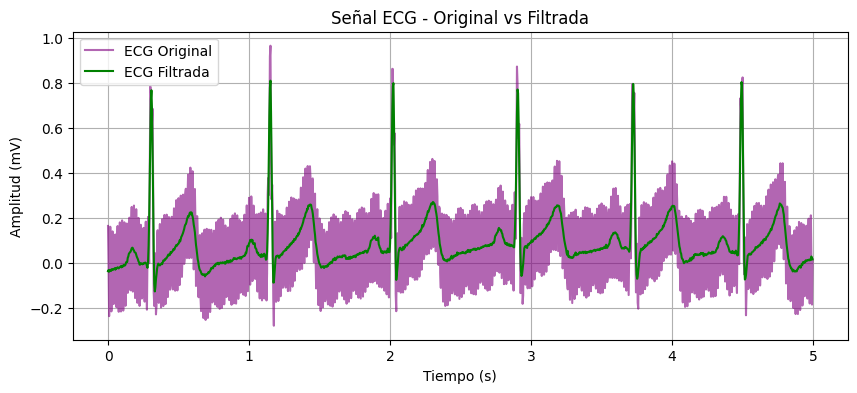

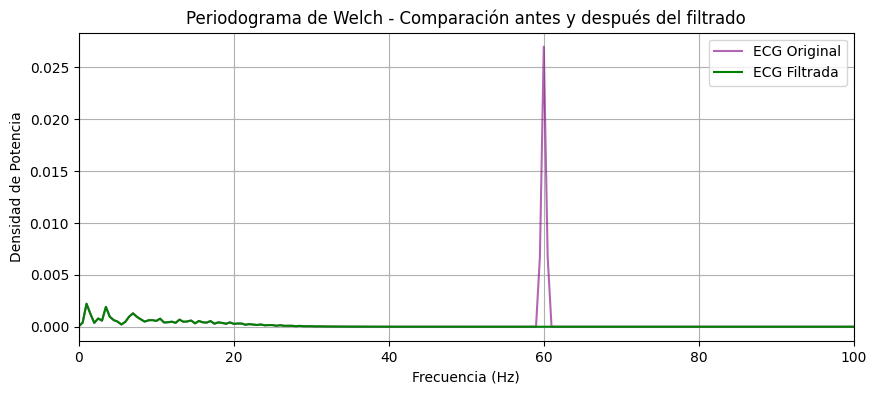

In [ ]:
#Filtrado del ruido de 60 Hz en el dominio frecuencial

# Calculamos la FFT de la señal ECG original
ECG_FFT = np.fft.fft(ecg_original)
N_ecg = len(ecg_original)

# Creamos el vector de frecuencias en Hz
F_ecg = np.arange(0, N_ecg) * fs_ecg / N_ecg

# Identificamos los índices correspondientes a 60 Hz y su simétrico
idx_60 = np.where((F_ecg >= 59) & (F_ecg <= 61))[0]
idx_simetrico = N_ecg - idx_60

# Creamos el espectro filtrado anulando los coeficientes de 60 Hz
ECG_FFT_filtrada = ECG_FFT.copy()
ECG_FFT_filtrada[idx_60] = 0
ECG_FFT_filtrada[idx_simetrico] = 0

# Aplicamos la IFFT para reconstruir la señal filtrada en el tiempo
ecg_filtrada = np.real(np.fft.ifft(ECG_FFT_filtrada))

# Graficamos la señal original vs filtrada
t_ecg = np.arange(0, N_ecg) / fs_ecg
plt.figure(figsize=(10, 4))
plt.plot(t_ecg, ecg_original, label='ECG Original', color='purple', alpha=0.6)
plt.plot(t_ecg, ecg_filtrada, label='ECG Filtrada', color='green', linewidth=1.5)
plt.title('Señal ECG - Original vs Filtrada')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud (mV)')
plt.legend()
plt.grid(True)
plt.show()

#Comprobación con nuevo periodograma de Welch 
f_filtrada, Pxx_filtrada = pwelch(ecg_filtrada, fs_ecg, window='hann',
                                   nperseg=nperseg, noverlap=noverlap)

plt.figure(figsize=(10, 4))
plt.plot(f_w,        Pxx_w,        color='purple', label='ECG Original', alpha=0.6)
plt.plot(f_filtrada, Pxx_filtrada, color='green',  label='ECG Filtrada')
plt.title('Periodograma de Welch - Comparación antes y después del filtrado')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Densidad de Potencia')
plt.xlim(0, 100)
plt.legend()
plt.grid(True)
plt.show()

Las figuras muestran la señal ECG antes y después del filtrado, tanto en el dominio 
del tiempo como en frecuencia. En el dominio del tiempo, la señal original presenta 
una oscilación densa de alta frecuencia superpuesta que desaparece tras el filtrado, 
revelando claramente la morfología característica del ECG (ondas P, complejo QRS y 
onda T). El periodograma de Welch confirma la efectividad del proceso: el pico de 
60 Hz, dominante en la señal original, es completamente eliminado en la señal 
filtrada, mientras que las componentes fisiológicas por debajo de 20 Hz se conservan 
sin alteración.

**4.6 Realice un análisis de frecuencia a través del periodograma de welch de una señal de EEG de un paciente Sano y otra de un paciente con Parkinson de algún canal que en el proyecto 1 hayan identificado que presentaba diferencias, si no encontró diferencias, elija un par al azar. Realice un análisis comparativo de las señales según lo que le indiquen los
periodogramas. (Usar una ventana Hanning, y justificar la elección del solapamiento y el ancho de la ventaja)**

In [24]:
# Primero verificamos la estructura de los .mat 
import scipy.io as sio
import numpy as np

# ── Cambia estas rutas según donde tengas la carpeta ──
ruta_control   = r"C:\Users\valen\Downloads\datos_senales_datos_parkinson_cursos (1)\control\C001R_EP_reposo.mat"
ruta_parkinson = r"C:\Users\valen\Downloads\datos_senales_datos_parkinson_cursos (1)\parkinson\P001_EP_reposo.mat"

# Cargar un archivo de cada grupo
ctrl = sio.loadmat(ruta_control)
park = sio.loadmat(ruta_parkinson)

# Ver todas las llaves (variables) dentro del archivo
print("CONTROL")
for k, v in ctrl.items():
    if not k.startswith('__'):
        print(f"  Llave: '{k}' | Tipo: {type(v)} | Shape: {getattr(v, 'shape', 'N/A')}")

print("\nPARKINSON")
for k, v in park.items():
    if not k.startswith('__'):
        print(f"  Llave: '{k}' | Tipo: {type(v)} | Shape: {getattr(v, 'shape', 'N/A')}")



CONTROL
  Llave: 'data' | Tipo: <class 'numpy.ndarray'> | Shape: (8, 2000, 180)

PARKINSON
  Llave: 'data' | Tipo: <class 'numpy.ndarray'> | Shape: (8, 2000, 143)


Son 8 canales [C3, C2, CZ, C2, C4, O1, OZ, O2], donde se analizará el C3 y C4.

Calculando PSD - Canal C3 (índice 0)...
Calculando PSD - Canal C4 (índice 4)...
Listo.


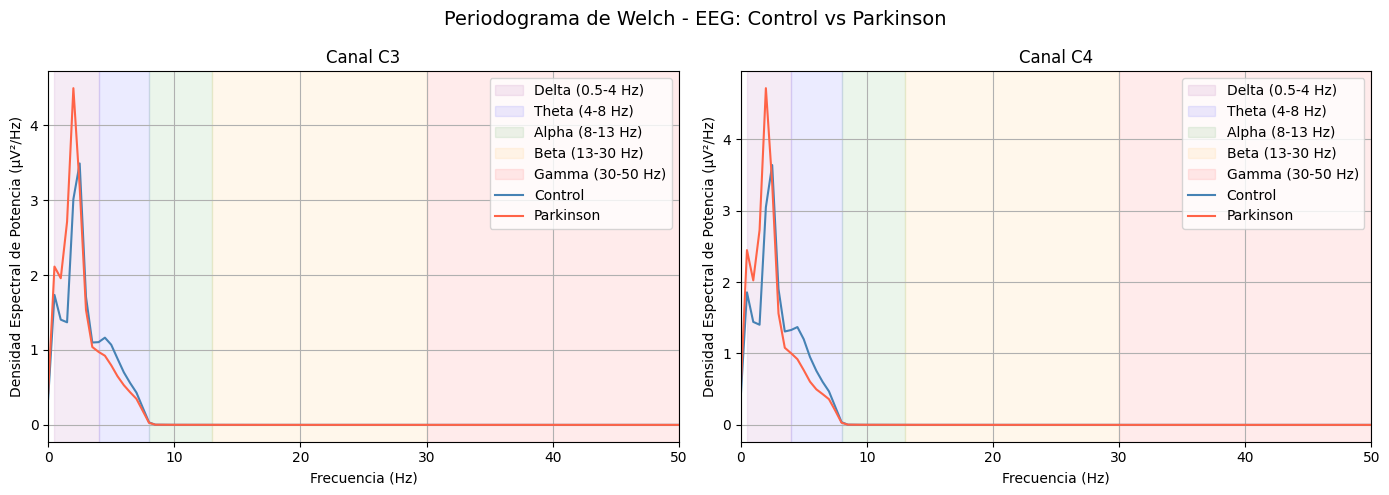


POTENCIA POR BANDA - CANAL C3
Banda                       Control    Parkinson      Dif %
  Delta (0.5-4 Hz)           6.7534       8.2289      +21.8%
  Theta (4-8 Hz)             2.8052       2.1848      -22.1%
  Alpha (8-13 Hz)            0.0134       0.0118      -12.0%
  Beta  (13-30 Hz)           0.0033       0.0034       +2.5%
  Gamma (30-50 Hz)           0.0010       0.0010       +3.6%

POTENCIA POR BANDA - CANAL C4
Banda                       Control    Parkinson      Dif %
  Delta (0.5-4 Hz)           7.1654       8.6044      +20.1%
  Theta (4-8 Hz)             3.1433       2.1490      -31.6%
  Alpha (8-13 Hz)            0.0159       0.0133      -16.2%
  Beta  (13-30 Hz)           0.0040       0.0038       -4.5%
  Gamma (30-50 Hz)           0.0012       0.0012       -3.1%


In [ ]:
import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch as pwelch
import os

fs_eeg = 250
idx_canal_1 = 0  # Canal C3 (confirmado por el profesor)
idx_canal_2 = 4  # Canal C4 (confirmado por el profesor)

ruta_ctrl = r"C:\Users\valen\Downloads\datos_senales_datos_parkinson_cursos (1)\control"
ruta_park = r"C:\Users\valen\Downloads\datos_senales_datos_parkinson_cursos (1)\parkinson"

# --- Parámetros del Periodograma de Welch ---
# Ventana Hanning de 500 muestras = 2 segundos a 250 Hz.
# Provee resolución frecuencial de 0.5 Hz, suficiente para discriminar
# las bandas EEG clásicas (delta, theta, alpha, beta, gamma).
# Solapamiento del 50% (250 muestras): valor estándar que balancea
# reducción de varianza y uso eficiente de los datos.
nperseg  = 500
noverlap = 250

def cargar_psd_promedio(ruta_carpeta, idx_canal, fs, nperseg, noverlap):
    """
    Carga todos los archivos .mat de una carpeta, extrae el canal indicado,
    concatena todas las épocas y calcula el PSD promedio con Welch.
    
    Parámetros
    ----------
    ruta_carpeta : str   → ruta a la carpeta con los .mat
    idx_canal    : int   → índice del canal a extraer (eje 0 del array)
    fs           : int   → frecuencia de muestreo en Hz
    nperseg      : int   → ancho de ventana en muestras
    noverlap     : int   → solapamiento en muestras
    
    Retorna
    -------
    f   : array de frecuencias (Hz)
    psd : densidad espectral de potencia promediada entre sujetos
    """
    archivos = sorted([f for f in os.listdir(ruta_carpeta) if f.endswith('.mat')])
    psds = []
    for archivo in archivos:
        data = sio.loadmat(os.path.join(ruta_carpeta, archivo))['data']
        # data shape: (8 canales, 2000 muestras, N épocas)
        # Concatenamos todas las épocas del canal para obtener una señal larga
        señal_canal = data[idx_canal, :, :].flatten(order='F')
        f, psd = pwelch(señal_canal, fs=fs, window='hann',
                        nperseg=nperseg, noverlap=noverlap)
        psds.append(psd)
    psd_promedio = np.mean(psds, axis=0)
    return f, psd_promedio

# PSD promedio para cada grupo y canal
print("Calculando PSD - Canal C3 (índice 0)...")
f_C3_ctrl, psd_C3_ctrl = cargar_psd_promedio(ruta_ctrl, idx_canal_1, fs_eeg, nperseg, noverlap)
f_C3_park, psd_C3_park = cargar_psd_promedio(ruta_park, idx_canal_1, fs_eeg, nperseg, noverlap)

print("Calculando PSD - Canal C4 (índice 4)...")
f_C4_ctrl, psd_C4_ctrl = cargar_psd_promedio(ruta_ctrl, idx_canal_2, fs_eeg, nperseg, noverlap)
f_C4_park, psd_C4_park = cargar_psd_promedio(ruta_park, idx_canal_2, fs_eeg, nperseg, noverlap)
print("Listo.")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Periodograma de Welch - EEG: Control vs Parkinson', fontsize=14)

for a in axes:
    a.axvspan(0.5,  4,  alpha=0.08, color='purple', label='Delta (0.5-4 Hz)')
    a.axvspan(4,    8,  alpha=0.08, color='blue',   label='Theta (4-8 Hz)')
    a.axvspan(8,   13,  alpha=0.08, color='green',  label='Alpha (8-13 Hz)')
    a.axvspan(13,  30,  alpha=0.08, color='orange', label='Beta (13-30 Hz)')
    a.axvspan(30,  50,  alpha=0.08, color='red',    label='Gamma (30-50 Hz)')

ax = axes[0]
ax.plot(f_C3_ctrl, psd_C3_ctrl, color='steelblue', label='Control')
ax.plot(f_C3_park, psd_C3_park, color='tomato',    label='Parkinson')
ax.set_title('Canal C3')
ax.set_xlabel('Frecuencia (Hz)')
ax.set_ylabel('Densidad Espectral de Potencia (µV²/Hz)')
ax.set_xlim(0, 50)
ax.legend()
ax.grid(True)

ax = axes[1]
ax.plot(f_C4_ctrl, psd_C4_ctrl, color='steelblue', label='Control')
ax.plot(f_C4_park, psd_C4_park, color='tomato',    label='Parkinson')
ax.set_title('Canal C4')
ax.set_xlabel('Frecuencia (Hz)')
ax.set_ylabel('Densidad Espectral de Potencia (µV²/Hz)')
ax.set_xlim(0, 50)
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

# Análisis numérico por bandas 
bandas = {
    'Delta (0.5-4 Hz)' : (0.5, 4),
    'Theta (4-8 Hz)'   : (4,   8),
    'Alpha (8-13 Hz)'  : (8,  13),
    'Beta  (13-30 Hz)' : (13, 30),
    'Gamma (30-50 Hz)' : (30, 50),
}

def potencia_banda(f, psd, fmin, fmax):
    """Integra la PSD en una banda de frecuencia usando la regla del trapecio."""
    idx = np.where((f >= fmin) & (f <= fmax))
    return np.trapz(psd[idx], f[idx])

for nombre_canal, (f_ctrl, psd_ctrl, f_park, psd_park) in {
    'C3': (f_C3_ctrl, psd_C3_ctrl, f_C3_park, psd_C3_park),
    'C4': (f_C4_ctrl, psd_C4_ctrl, f_C4_park, psd_C4_park),
}.items():
    print(f"\nPOTENCIA POR BANDA - CANAL {nombre_canal}")
    print(f"{'Banda':<22} {'Control':>12} {'Parkinson':>12} {'Dif %':>10}")
    
    for banda, (fmin, fmax) in bandas.items():
        p_ctrl = potencia_banda(f_ctrl, psd_ctrl, fmin, fmax)
        p_park = potencia_banda(f_park, psd_park, fmin, fmax)
        dif    = (p_park - p_ctrl) / p_ctrl * 100 # Cuanto cambia la potencia de Parkinson respecto al control,
                                                  # expresado como porcentaje del valor control
        print(f"  {banda:<20} {p_ctrl:>12.4f} {p_park:>12.4f} {dif:>+10.1f}%")

Los periodogramas de Welch de los canales C3 y C4 muestran que la banda delta 
(0.5–4 Hz) es la dominante en ambos grupos, con un incremento significativo en 
los pacientes con Parkinson respecto a los controles (+21.8% en C3, +20.1% en C4). 
En contraste, la banda theta presentó una reducción en Parkinson (-22.1% en C3, 
-31.6% en C4), resultado que contrasta con lo reportado por Camacho et al. (2023), 
quienes encontraron un incremento generalizado de theta en Parkinson, aunque los 
mismos autores reconocen que este hallazgo no fue consistente entre todos los 
datasets analizados [1]. La banda alpha también mostró una reducción (-12.0% en C3, 
-16.2% en C4), coherente con el modelo de disfunción tálamo-cortical, donde el 
enlentecimiento en los lazos tálamo-corticales desplaza la actividad oscilatoria 
hacia frecuencias más bajas, incrementando la potencia delta y reduciendo la 
potencia alpha [1]. Las bandas beta y gamma no mostraron diferencias relevantes entre grupos, 
lo esperado para EEG de superficie donde estas diferencias son más detectables con 
registros intracerebrales. El patrón fue consistente en ambos canales, lo que confirma que las diferencias encontradas entre grupos no dependen de un canal específico sino que se presentan de forma consistente en ambos hemisferios cerebrales.



### **CONCLUSIONES**
- Si bien el Teorema de Nyquist establece una frecuencia de muestreo 
mínima de 320 Hz para la señal analizada, en la práctica fue necesario usar 1600 Hz 
para representar fielmente su dinámica. La FFT identificó correctamente los tres 
componentes frecuenciales (40, 80 y 160 Hz), confirmando su utilidad para descomponer 
señales multicomponente de forma eficiente.

- La IFFT demostró ser la operación inversa exacta de la FFT, 
reconstruyendo la señal original sin pérdida de información. Su aplicación sobre 
un espectro modificado selectivamente constituye un filtro en el dominio frecuencial, 
lo que permitió extraer cada componente sinusoidal de forma independiente.

- El periodograma de Welch permitió identificar el ruido de red eléctrica 
(60 Hz) en la señal ECG. Una vez detectado, se eliminó mediante filtrado espectral 
en el dominio de la frecuencia, preservando íntegramente las componentes fisiológicas 
de interés por debajo de 40 Hz, lo cual fue verificado con un nuevo periodograma 
de Welch sobre la señal filtrada.

- El análisis frecuencial por periodograma de Welch reveló diferencias 
espectrales entre sujetos control y pacientes con Parkinson, principalmente en la 
banda delta, cuyo incremento en Parkinson es coherente con el modelo de disfunción 
tálamo-cortical reportado en la literatura [1]. Esto evidencia el potencial del 
análisis frecuencial como herramienta para caracterizar bioseñales en contextos clínicos.

### Referencia

[1] Camacho, M., et al. (2023). Spectral features of resting-state EEG in 
    Parkinson's Disease: A multicenter study using functional data analysis. 
    *Clinical Neurophysiology*, 152, 91–105. 
    https://doi.org/10.1016/j.clinph.2023.03.363